In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import pandas as pd
import os

import fitting_neural.load_homann_data as load_homann
import utils.saveload as sl

# Cross-validation (Fig. 2)

In [2]:
def plot_bar_cv(weighting_cv, drop_type_cv, combine_m=False, plot_pred=False):

    # plt.rcParams.update({'font.size': 11}) 
    plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')

    path_save = os.path.join(sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_neural_pred')
    sl.make_long_dir(path_save)

    # Paths and models
    path_cnov = sl.get_rootpath() / 'data' / 'grid_search_results'
    path_snov = sl.get_rootpath() / 'data' / 'grid_search_results'

    models = ['cnov_leaky', 
              'snov-complex-leaky']
    # models = ['cnov_fr', 
    #           'snov-complex-fr']
    names  = ['Count-based',
              'Similarity-based']
    # names  = ['Counts\n(flr)',
    #           'Similarity\n(flr)']
    sets   = [None,
              1]
    # sets   = [None,
    #           1]
    paths  = [os.path.join(path_cnov, f'{models[0]}/'), 
              os.path.join(path_snov, f'{models[1]}_set{sets[1]}_sep/combined_data/')]
    params = [['alph_leak','eps','num_states_model'],
              ['alph_leak','eps','cdens','knum']]
    # params = [['k_alph','num_states_model'],
    #           ['k_alph','cdens','knum']]
    
    # Homann info
    exp_len = [5,7,4,4]
    xl = ['$L$','$L\'$','$M$','$M$']
    yl = ['$\\Delta N$','$\\Delta N$','$\\Delta N$','$N_{\\infty}$']
    df_sim_data = pd.DataFrame({'id':        np.arange(np.sum(exp_len)),
                                'exp_id':    np.concatenate([[i]*exp_len[i] for i in range(len(exp_len))]),
                                'id_in_exp': np.concatenate([np.arange(exp_len[i]) for i in range(len(exp_len))])})
    combine_exp_id = [2,3] if combine_m else None # combine m and m_steady

    # Colors
    vmax   = 4 + 2
    cnorm  = colors.Normalize(vmin=0, vmax=vmax)
    cmap_b = plt.cm.get_cmap('Blues')
    smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b) # blue (cnov)
    cmap_r = plt.cm.get_cmap('Reds')
    smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r) # red (snov-complex)
    cb = [smap_b.to_rgba(i) for i in range(vmax)][::-1] + [smap_r.to_rgba(i) for i in range(vmax)]

    cols_models = [
              cb[0],
              cb[-1]
              ]

    # Initialize variables
    errors       = []
    grids        = []
    mse_refitted = []
    best_params  = []
    pred         = []

    train        = []
    test         = []
    train_err    = []
    test_err     = []

    # Load data for plotting
    for i in range(len(models)):

        # Load cross-validation errors (including their resampled variability)
        error_name = f'cv_errors_outerjack-cv-drop-{drop_type_cv}-{weighting_cv}.csv' 
        errors_i = pd.read_csv(os.path.join(paths[i], error_name))
        errors.append(errors_i)
        train.append(errors_i['train_error'].values[0])
        test.append(errors_i['test_error'].values[0])
        train_err.append(errors_i['train_error_se'].values[0])
        test_err.append(errors_i['test_error_se'].values[0])

        # Load cross-validation errors (for normal cv)
        mse_refitted_name = f'cv_all_all_errors_outerjack-cv-drop-{drop_type_cv}-{weighting_cv}.csv'
        mse_refitted_i = pd.read_csv(os.path.join(paths[i], mse_refitted_name))
        mse_refitted.append(mse_refitted_i)

        # Load grid 
        grid_name = f'grid_jackknife-loo-drop-{drop_type_cv}-{weighting_cv}.csv'
        grid_i = pd.read_csv(os.path.join(paths[i], grid_name))
        grids.append(grid_i)

        if plot_pred:
            # Extract predicted homann stats of best model for each outer and inner resampling set
            predbest_i = []
            best_params_i  = []
            for outer_j in mse_refitted_i['outer_resampling_id'].unique():

                # if drop_type_cv=='exp':
                #     mask_outer_j = df_sim_data['exp_id'].isin([outer_j])
                # elif drop_type_cv=='sample':
                #     mask_outer_j = np.zeros(df_sim_data.shape[0], dtype=bool)
                #     mask_outer_j[outer_j] = True

                predbest_outer_j = np.nan * np.ones(len(df_sim_data)) 
                best_params_outer_j = []
                for inner_j in mse_refitted_i[mse_refitted_i['outer_resampling_id']==outer_j]['resampling_id'].values:

                    fitbest_ij  = mse_refitted_i[(mse_refitted_i['outer_resampling_id']==outer_j) & (mse_refitted_i['resampling_id']==inner_j)] # train / test error of best model
                    params_ij   = grid_i.loc[grid_i['grid_id']==fitbest_ij['gid'].values[0], ['grid_id']+params[i]] # parameters of best model
                    params_ij['outer_resampling_id'] = outer_j
                    params_ij['resampling_id'] = inner_j
                    best_params_outer_j.append(params_ij)

                    predbest_ij = np.load(os.path.join(paths[i], f'grid_{int(fitbest_ij["gid"].values[0])}/pred-test-all__{weighting_cv}__outerjack-cv_drop-{drop_type_cv}.npy'), allow_pickle=True) # shape: num_samples (resampling set) x num_resampling (inner) x num_resampling (outer)
                    if drop_type_cv=='exp': ## STILL NEEDS TO BE CHECKED
                        idx_lower = np.sum(exp_len[:inner_j]) if inner_j>0 else 0
                        idx_upper = np.sum(exp_len[:inner_j+1]) if inner_j<len(exp_len)-1 else np.sum(exp_len)
                        predbest_outer_j.append(predbest_ij[idx_lower:idx_upper,inner_j])
                    elif drop_type_cv=='sample':
                        inner_j1 = inner_j if inner_j<outer_j else inner_j+1 # since outer_j sample is dropped
                        predbest_outer_j[inner_j1] = predbest_ij[inner_j, inner_j ,outer_j]

                best_params_outer_j  = pd.concat(best_params_outer_j, axis=0)
                if drop_type_cv=='exp':
                    predbest_outer_j = np.concatenate(predbest_outer_j)
                elif drop_type_cv=='sample':
                    predbest_outer_j = np.array(predbest_outer_j)
                best_params_i.append(best_params_outer_j)
                predbest_i.append(predbest_outer_j)

            best_params_i  = pd.concat(best_params_i, axis=0)
            if drop_type_cv=='exp':
                predbest_i     = np.array(predbest_i) # shape: ?
            elif drop_type_cv=='sample':
                predbest_i     = np.array(predbest_i) # shape: (num_outer * num_inner)
            best_params.append(best_params_i)
            pred.append(predbest_i)

    # Plot cross-validation errors
    ########################################################################################################################
    f,ax = plt.subplots(1, 2, figsize=(6.9, 2.3))
    pv0 = ax[0].bar(x=np.arange(len(models)), height=train, yerr=train_err, color=cols_models, ecolor='k', capsize=2)
    pv1 = ax[1].bar(x=np.arange(len(models)), height=test, yerr=test_err, color=cols_models, ecolor='k', capsize=2)
    ax[0].bar_label(pv0, fmt='%.e', label_type='center') #, padding=3, fontsize=10)
    ax[1].bar_label(pv1, fmt='%.e', label_type='center') #, padding=3, fontsize=10)

    ax[0].set_xticks(np.arange(len(models)), names)
    ax[1].set_xticks(np.arange(len(models)), names)
    ax[0].set_ylabel('Fitting error')
    ax[1].set_ylabel('Cross-validation error')
    ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax[0].spines[['top', 'right']].set_visible(False)
    ax[1].spines[['top', 'right']].set_visible(False)
    f.tight_layout(pad=0.4)
    f.savefig(os.path.join(path_save, f'FIG2_DE_fit-cv_equal-{weighting_cv}_drop-{drop_type_cv}.svg'))
    # f.suptitle(f'Cross-validation errors (cv: {weighting_cv}, drop-{drop_type_cv})')

    if plot_pred:
        #####################################################################################################################
        # Load Homann data
        homann_data = load_homann.load_exp_homann(cluster=False)
        homann_lstd = load_homann.load_exp_homann(cluster=False,type='lowerstd')
        homann_ustd = load_homann.load_exp_homann(cluster=False,type='upperstd')
        # Set novelty response for L'=0 to zero
        homann_data[1][1][0] = 0 #homann_data[1][1][0]-delta_homann
        homann_lstd[1][1][0] = 0 #homann_lstd[1][1][0]-delta_homann
        homann_ustd[1][1][0] = 0 #homann_ustd[1][1][0]-delta_homann

        # ylim = [[0,0.05],[0,0.05],[0,0.06],[0.04,0.1]]
        yeps = 0.0025
        ylim = [[0,0.05],[0,0.05],[0.01,0.06],[0.04,0.1]]
        xlim = [[0-0.9,40+0.9],[0-4,150+4],[3-0.5,12+0.5],[3-0.5,12+0.5]]
        xt   = [[0,20,40],[0,50,100,150],[3,6,9,12],[3,6,9,12]]
        xl_homann  = ['Sequence repetitions (L)','Recovery repetitions (L\')','Length of sequence (M)','Length of sequence (M)']
        yl_homann  = ['Novelty response $\Delta N$','$\Delta$ N','$\Delta$ N','Steady state $N_{\infty}$']

        # Plot predicted homann stats (with cross-validated fit)

        f_test, ax_test = plt.subplots(1,3,figsize=(8.3,3.2))

        ax_inset = ax_test[2].inset_axes([0.55,0.6,0.4,0.4])
        ax_test  = np.concatenate([ax_test,np.array([ax_inset])])
        
        for i in range(len(models)):
            cc = 0
            fi, axi = plt.subplots(1, 4, figsize=(12, 4))

            pred_i = pred[i]
            pred_i_mean = np.nanmean(pred_i, axis=0) # average across outer resamplings
            pred_i_se   = np.nanstd(pred_i, axis=0) / np.sqrt(pred_i.shape[0]) # se across outer resamplings
            
            for j in range(len(exp_len)):
                pred_ij   = pred_i[:,cc:cc+exp_len[j]]
                pred_ij_mean = pred_i_mean[cc:cc+exp_len[j]]
                pred_ij_se   = pred_i_se[cc:cc+exp_len[j]]
                cc += exp_len[j]

                if i==len(models)-1:
                    # Plot Homann data
                    ax_test[j].plot(homann_data[j][0], homann_data[j][1], 'o-', c='k', label='Homann et al.')
                    ax_test[j].errorbar(x=homann_data[j][0], y=homann_data[j][1], yerr=[homann_data[j][1]-homann_lstd[j][1],homann_ustd[j][1]-homann_data[j][1]], color='k')

                if j==len(exp_len)-1:
                    markersize = 3
                    label_font = 10
                    plot_line = False
                else:
                    markersize = 6
                    label_font = 11
                    plot_line = True
                
                # Plot individual resampling (combined figure)
                for kk in range(pred_ij.shape[1]):
                    ax_test[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]), pred_ij[:,kk], c=cols_models[i], s=5, alpha=0.3)
                ax_test[j].plot(homann_data[j][0], pred_ij_mean, 'o-', c=cols_models[i], label=f'{names[i]}', lw=2, markersize=markersize)
                ax_test[j].errorbar(homann_data[j][0], pred_ij_mean, yerr=pred_ij_se, fmt='o', c=cols_models[i], lw=2)

                # Plot individual resampling (separate figure per model)
                for kk in range(pred_ij.shape[1]):
                    axi[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]), pred_ij[:,kk], c=cols_models[i], s=5, alpha=0.3)
                axi[j].plot(homann_data[j][0], pred_ij_mean, 'o-', c=cols_models[i], label=f'{names[i]}', lw=2, markersize=markersize)
                axi[j].errorbar(homann_data[j][0], pred_ij_mean, yerr=pred_ij_se, fmt='o', c=cols_models[i], lw=2)

                # Plot Homann data
                axi[j].plot(homann_data[j][0], homann_data[j][1], 'o-', c='k', label='Homann et al.')
                axi[j].errorbar(x=homann_data[j][0], y=homann_data[j][1], yerr=[homann_data[j][1]-homann_lstd[j][1],homann_ustd[j][1]-homann_data[j][1]], color='k')
            
                # Format individual plots
                axi[j].set_ylabel(yl_homann[j])
                axi[j].set_ylim(np.array(ylim[j])+yeps*np.array([-1,1])) #ylim[j]
        
                axi[j].set_xlabel(xl_homann[j])
                axi[j].set_xlim(np.array(xlim[j]))
                axi[j].set_xticks(xt[j]) #homann_data[j][0]

                axi[j].spines['right'].set_visible(False)
                axi[j].spines['top'].set_visible(False)

                # Format combined plot
                ax_test[j].set_ylabel(yl_homann[j])
                ax_test[j].set_ylim(np.array(ylim[j])+yeps*np.array([-1,1])) #ylim[j]
                
                ax_test[j].set_xlabel(xl_homann[j])
                ax_test[j].set_xlim(np.array(xlim[j]))
                ax_test[j].set_xticks(xt[j]) #homann_data[j][0]
                
                ax_test[j].spines['right'].set_visible(False)
                ax_test[j].spines['top'].set_visible(False)

                if j==0:
                    axi[j].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
                    ax_test[j].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
                    # axl[0].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)

                if j==len(exp_len)-1:
                    axi[j].set_xlabel('')
                    axi[j].xaxis.set_tick_params(labelsize=10)
                    axi[j].yaxis.set_tick_params(labelsize=10)

                    ax_test[j].set_xlabel('')
                    ax_test[j].xaxis.set_tick_params(labelsize=10)
                    ax_test[j].yaxis.set_tick_params(labelsize=10)
                        
            # fi.suptitle(f'Predicted homann stats: {names[i]}'.replace('\n', ' '))
            fi.tight_layout(pad=0.4)
            fi.show()
        
        # f_test.suptitle('Average predictions across resamplings (cross-validated fit)')
        f_test.tight_layout(pad=0.4)
        f_test.savefig(os.path.join(path_save, f'FIG2_F_pred-cv_equal-{weighting_cv}_drop-{drop_type_cv}.svg'))

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/606438910.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/606438910.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')


Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/606438910.py:212: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_test[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]), pred_ij[:,kk], c=cols_models[i], s=5, alpha=0.3)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/606438910.py:218: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axi[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]),

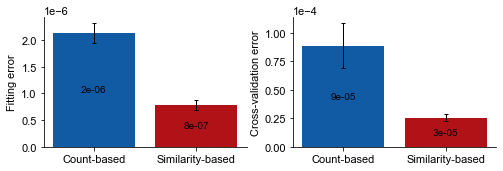

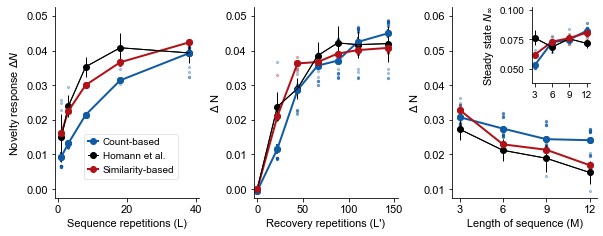

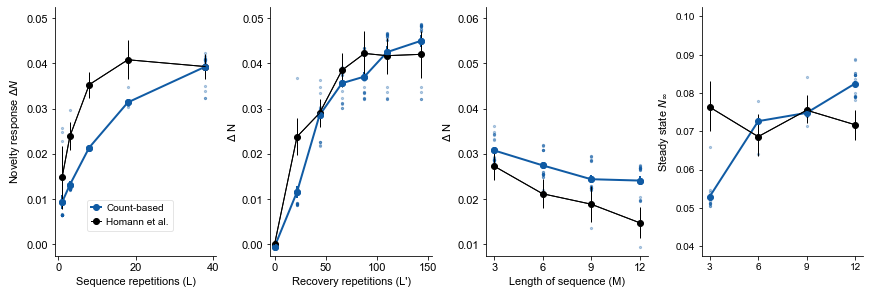

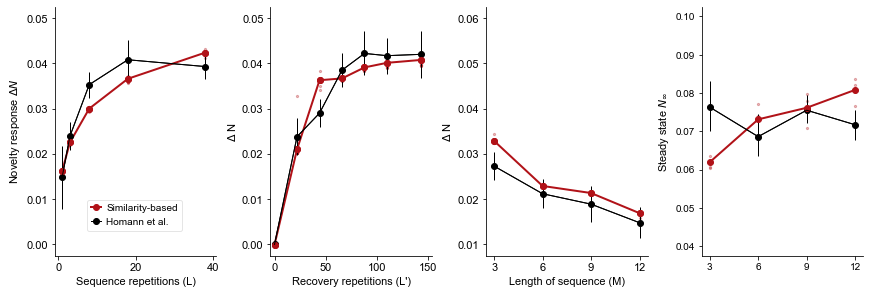

In [3]:
plot_bar_cv(weighting_cv='equal-samples', drop_type_cv='sample', plot_pred=True)

# Cross-validation all leaky models (Fig. S4)

In [4]:
def plot_bar_cv_si(weighting_cv, drop_type_cv, combine_m=False, plot_pred=False):

    plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')

    path_save = os.path.join(sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_neural_pred')
    sl.make_long_dir(path_save)

    # Paths and models
    path_cnov = sl.get_rootpath() / 'data' / 'grid_search_results'
    path_snov = sl.get_rootpath() / 'data' / 'grid_search_results'
    models = ['cnov_fr', 
                'cnov_leaky',
                'snov-complex-fr',
                'snov-complex-leaky']
    names  = ['Counts\n(fixed-rate)',
                'Counts\n(leaky)',
                'Sim.\n(fixed-rate)',
                'Sim.\n(leaky)']
    sets   = [None,
              None,
              1,
              1]
    paths  = [os.path.join(path_cnov, f'{models[0]}/'), 
              os.path.join(path_cnov, f'{models[1]}/'), 
              os.path.join(path_snov, f'{models[2]}_set{sets[2]}_sep/combined_data/'),
              os.path.join(path_snov, f'{models[3]}_set{sets[3]}_sep/combined_data/')]
    params = [['k_alph','num_states_model'],
              ['alph_leak','eps','num_states_model'],
              ['k_alph','cdens','knum'],
              ['alph_leak','eps','cdens','knum']]
    
    # Homann info
    exp_len = [5,7,4,4]
    xl = ['$L$','$L\'$','$M$','$M$']
    yl = ['$\\Delta N$','$\\Delta N$','$\\Delta N$','$N_{\\infty}$']
    df_sim_data = pd.DataFrame({'id':        np.arange(np.sum(exp_len)),
                                'exp_id':    np.concatenate([[i]*exp_len[i] for i in range(len(exp_len))]),
                                'id_in_exp': np.concatenate([np.arange(exp_len[i]) for i in range(len(exp_len))])})
    combine_exp_id = [2,3] if combine_m else None # combine m and m_steady

    # Colors
    vmax   = 4 + 2
    cnorm  = colors.Normalize(vmin=0, vmax=vmax)

    cmap_p = plt.cm.get_cmap('Purples')
    smap_p = cm.ScalarMappable(norm=cnorm, cmap=cmap_p) # purple (cnov, fixed-rate)

    cmap_b = plt.cm.get_cmap('Blues')
    smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b) # blue (cnov, leaky)

    cmap_o = plt.cm.get_cmap('Oranges')
    smap_o = cm.ScalarMappable(norm=cnorm, cmap=cmap_o) # orange (snov-complex, fixed-rate)

    cmap_r = plt.cm.get_cmap('Reds')
    smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r) # red (snov-complex, leaky)

    cols_models = [smap_p.to_rgba(vmax-2),
            smap_b.to_rgba(vmax-1),
            smap_o.to_rgba(vmax-2),
            smap_r.to_rgba(vmax-1)]

    # Initialize variables
    errors       = []
    grids        = []
    mse_refitted = []
    best_params  = []
    pred         = []

    train        = []
    test         = []
    train_err    = []
    test_err     = []

    # Load data for plotting
    for i in range(len(models)):

        # Load cross-validation errors (including their resampled variability)
        error_name = f'cv_errors_outerjack-cv-drop-{drop_type_cv}-{weighting_cv}.csv' 
        errors_i = pd.read_csv(os.path.join(paths[i], error_name))
        errors.append(errors_i)
        train.append(errors_i['train_error'].values[0])
        test.append(errors_i['test_error'].values[0])
        train_err.append(errors_i['train_error_se'].values[0])
        test_err.append(errors_i['test_error_se'].values[0])

        # Load cross-validation errors (for normal cv)
        mse_refitted_name = f'cv_all_all_errors_outerjack-cv-drop-{drop_type_cv}-{weighting_cv}.csv'
        mse_refitted_i = pd.read_csv(os.path.join(paths[i], mse_refitted_name))
        mse_refitted.append(mse_refitted_i)

        # Load grid 
        grid_name = f'grid_jackknife-loo-drop-{drop_type_cv}-{weighting_cv}.csv'
        grid_i = pd.read_csv(os.path.join(paths[i], grid_name))
        grids.append(grid_i)

        if plot_pred:
            # Extract predicted homann stats of best model for each outer and inner resampling set
            predbest_i = []
            best_params_i  = []
            for outer_j in mse_refitted_i['outer_resampling_id'].unique():

                # if drop_type_cv=='exp':
                #     mask_outer_j = df_sim_data['exp_id'].isin([outer_j])
                # elif drop_type_cv=='sample':
                #     mask_outer_j = np.zeros(df_sim_data.shape[0], dtype=bool)
                #     mask_outer_j[outer_j] = True

                predbest_outer_j = np.nan * np.ones(len(df_sim_data)) 
                best_params_outer_j = []
                for inner_j in mse_refitted_i[mse_refitted_i['outer_resampling_id']==outer_j]['resampling_id'].values:

                    fitbest_ij  = mse_refitted_i[(mse_refitted_i['outer_resampling_id']==outer_j) & (mse_refitted_i['resampling_id']==inner_j)] # train / test error of best model
                    params_ij   = grid_i.loc[grid_i['grid_id']==fitbest_ij['gid'].values[0], ['grid_id']+params[i]] # parameters of best model
                    params_ij['outer_resampling_id'] = outer_j
                    params_ij['resampling_id'] = inner_j
                    best_params_outer_j.append(params_ij)

                    predbest_ij = np.load(os.path.join(paths[i], f'grid_{int(fitbest_ij["gid"].values[0])}/pred-test-all__{weighting_cv}__outerjack-cv_drop-{drop_type_cv}.npy'), allow_pickle=True) # shape: num_samples (resampling set) x num_resampling (inner) x num_resampling (outer)
                    if drop_type_cv=='exp': ## STILL NEEDS TO BE CHECKED
                        idx_lower = np.sum(exp_len[:inner_j]) if inner_j>0 else 0
                        idx_upper = np.sum(exp_len[:inner_j+1]) if inner_j<len(exp_len)-1 else np.sum(exp_len)
                        predbest_outer_j.append(predbest_ij[idx_lower:idx_upper,inner_j])
                    elif drop_type_cv=='sample':
                        inner_j1 = inner_j if inner_j<outer_j else inner_j+1 # since outer_j sample is dropped
                        predbest_outer_j[inner_j1] = predbest_ij[inner_j, inner_j ,outer_j]

                best_params_outer_j  = pd.concat(best_params_outer_j, axis=0)
                if drop_type_cv=='exp':
                    predbest_outer_j = np.concatenate(predbest_outer_j)
                elif drop_type_cv=='sample':
                    predbest_outer_j = np.array(predbest_outer_j)
                best_params_i.append(best_params_outer_j)
                predbest_i.append(predbest_outer_j)

            best_params_i  = pd.concat(best_params_i, axis=0)
            if drop_type_cv=='exp':
                predbest_i     = np.array(predbest_i) # shape: ?
            elif drop_type_cv=='sample':
                predbest_i     = np.array(predbest_i) # shape: (num_outer * num_inner)
            best_params.append(best_params_i)
            pred.append(predbest_i)

    # Plot cross-validation errors
    ########################################################################################################################
    f,ax = plt.subplots(1, 2, figsize=(7.5, 2.3))
    pv0 = ax[0].bar(x=np.arange(len(models)), height=train, yerr=train_err, color=cols_models, ecolor='k', capsize=2)
    pv1 = ax[1].bar(x=np.arange(len(models)), height=test, yerr=test_err, color=cols_models, ecolor='k', capsize=2)
    ax[0].bar_label(pv0, fmt='%.e', label_type='center') #, padding=3, fontsize=10)
    ax[1].bar_label(pv1, fmt='%.e', label_type='center') #, padding=3, fontsize=10)

    ax[0].set_xticks(np.arange(len(models)), names)
    ax[1].set_xticks(np.arange(len(models)), names)
    ax[0].set_ylabel('Fitting error')
    ax[1].set_ylabel('Cross-validation error')
    ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax[0].spines[['top', 'right']].set_visible(False)
    ax[1].spines[['top', 'right']].set_visible(False)
    f.tight_layout(pad=0.4)
    f.savefig(os.path.join(path_save, f'FIG_S4_fit-cv_equal-{weighting_cv}_drop-{drop_type_cv}.svg'))
    # f.suptitle(f'Cross-validation errors (cv: {weighting_cv}, drop-{drop_type_cv})')

    if plot_pred:
        #####################################################################################################################
        # Load Homann data
        homann_data = load_homann.load_exp_homann(cluster=False)
        homann_lstd = load_homann.load_exp_homann(cluster=False,type='lowerstd')
        homann_ustd = load_homann.load_exp_homann(cluster=False,type='upperstd')
        # Set novelty response for L'=0 to zero
        homann_data[1][1][0] = 0 #homann_data[1][1][0]-delta_homann
        homann_lstd[1][1][0] = 0 #homann_lstd[1][1][0]-delta_homann
        homann_ustd[1][1][0] = 0 #homann_ustd[1][1][0]-delta_homann

        # ylim = [[0,0.05],[0,0.05],[0,0.06],[0.04,0.1]]
        yeps = 0.0025
        ylim = [[0,0.05],[0,0.06],[0.01,0.07],[0.04,0.1]]
        xlim = [[0-0.9,40+0.9],[0-4,150+4],[3-0.5,12+0.5],[3-0.5,12+0.5]]
        xt   = [[0,20,40],[0,50,100,150],[3,6,9,12],[3,6,9,12]]
        xl_homann  = ['Sequence repetitions (L)','Recovery repetitions (L\')','Length of sequence (M)','Length of sequence (M)']
        yl_homann  = ['Novelty response $\Delta N$','$\Delta$ N','$\Delta$ N','Steady state $N_{\infty}$']

        # Plot predicted homann stats (with cross-validated fit)

        f_test, ax_test = plt.subplots(1,3,figsize=(8.3,3.2))

        ax_inset = ax_test[2].inset_axes([0.55,0.6,0.4,0.4])
        ax_test  = np.concatenate([ax_test,np.array([ax_inset])])
        
        for i in range(len(models)):
            cc = 0
            fi, axi = plt.subplots(1, 4, figsize=(12, 4))

            pred_i = pred[i]
            pred_i_mean = np.nanmean(pred_i, axis=0) # average across outer resamplings
            pred_i_se   = np.nanstd(pred_i, axis=0) / np.sqrt(pred_i.shape[0]) # se across outer resamplings
            
            for j in range(len(exp_len)):
                pred_ij   = pred_i[:,cc:cc+exp_len[j]]
                pred_ij_mean = pred_i_mean[cc:cc+exp_len[j]]
                pred_ij_se   = pred_i_se[cc:cc+exp_len[j]]
                cc += exp_len[j]

                if i==len(models)-1:
                    # Plot Homann data
                    ax_test[j].plot(homann_data[j][0], homann_data[j][1], 'o-', c='k', label='Homann et al.')
                    ax_test[j].errorbar(x=homann_data[j][0], y=homann_data[j][1], yerr=[homann_data[j][1]-homann_lstd[j][1],homann_ustd[j][1]-homann_data[j][1]], color='k')

                if j==len(exp_len)-1:
                    markersize = 3
                    label_font = 10
                    plot_line = False
                else:
                    markersize = 6
                    label_font = 11
                    plot_line = True
                
                # Plot individual resampling (combined figure)
                for kk in range(pred_ij.shape[1]):
                    ax_test[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]), pred_ij[:,kk], c=cols_models[i], s=5, alpha=0.3)
                ax_test[j].plot(homann_data[j][0], pred_ij_mean, 'o-', c=cols_models[i], label=f'{names[i]}', lw=2, markersize=markersize)
                ax_test[j].errorbar(homann_data[j][0], pred_ij_mean, yerr=pred_ij_se, fmt='o', c=cols_models[i], lw=2)

                # Plot individual resampling (separate figure per model)
                for kk in range(pred_ij.shape[1]):
                    axi[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]), pred_ij[:,kk], c=cols_models[i], s=5, alpha=0.3)
                axi[j].plot(homann_data[j][0], pred_ij_mean, 'o-', c=cols_models[i], label=f'{names[i]}', lw=2, markersize=markersize)
                axi[j].errorbar(homann_data[j][0], pred_ij_mean, yerr=pred_ij_se, fmt='o', c=cols_models[i], lw=2)

                # Plot Homann data
                axi[j].plot(homann_data[j][0], homann_data[j][1], 'o-', c='k', label='Homann et al.')
                axi[j].errorbar(x=homann_data[j][0], y=homann_data[j][1], yerr=[homann_data[j][1]-homann_lstd[j][1],homann_ustd[j][1]-homann_data[j][1]], color='k')
            
                # Format individual plots
                axi[j].set_ylabel(yl_homann[j])
                axi[j].set_ylim(np.array(ylim[j])+yeps*np.array([-1,1])) #ylim[j]
        
                axi[j].set_xlabel(xl_homann[j])
                axi[j].set_xlim(np.array(xlim[j]))
                axi[j].set_xticks(xt[j]) #homann_data[j][0]

                axi[j].spines['right'].set_visible(False)
                axi[j].spines['top'].set_visible(False)

                # Format combined plot
                ax_test[j].set_ylabel(yl_homann[j])
                ax_test[j].set_ylim(np.array(ylim[j])+yeps*np.array([-1,1])) #ylim[j]
                
                ax_test[j].set_xlabel(xl_homann[j])
                ax_test[j].set_xlim(np.array(xlim[j]))
                ax_test[j].set_xticks(xt[j]) #homann_data[j][0]
                
                ax_test[j].spines['right'].set_visible(False)
                ax_test[j].spines['top'].set_visible(False)

                if j==0:
                    axi[j].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
                    ax_test[j].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)
                    # axl[0].legend(fontsize=10,loc=(0.2,0.1),handlelength=1,borderaxespad=0,handletextpad=0.5,frameon=True,framealpha=0.5)

                if j==len(exp_len)-1:
                    axi[j].set_xlabel('')
                    axi[j].xaxis.set_tick_params(labelsize=10)
                    axi[j].yaxis.set_tick_params(labelsize=10)

                    ax_test[j].set_xlabel('')
                    ax_test[j].xaxis.set_tick_params(labelsize=10)
                    ax_test[j].yaxis.set_tick_params(labelsize=10)
                        
            # fi.suptitle(f'Predicted homann stats: {names[i]}'.replace('\n', ' '))
            fi.tight_layout(pad=0.4)
            fi.show()
        
        # f_test.suptitle('Average predictions across resamplings (cross-validated fit)')
        f_test.tight_layout(pad=0.4)
        f_test.savefig(os.path.join(path_save, f'FIG_S4_pred-cv_equal-{weighting_cv}_drop-{drop_type_cv}.svg'))

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/1495190991.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = plt.cm.get_cmap('Purples')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/1495190991.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/1495190991.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_o = 

Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis
Current path:/Users/sbecker/Projects/sim_nov/src/scripts/homann_analysis


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/1495190991.py:219: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_test[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]), pred_ij[:,kk], c=cols_models[i], s=5, alpha=0.3)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54531/1495190991.py:225: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axi[j].scatter([homann_data[j][0][kk]]*len(pred_ij[:,kk]

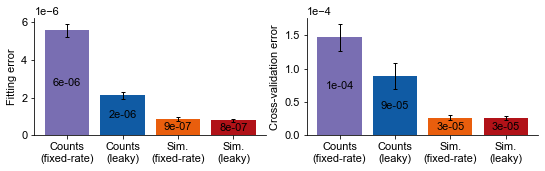

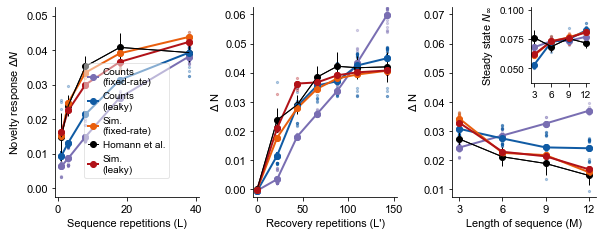

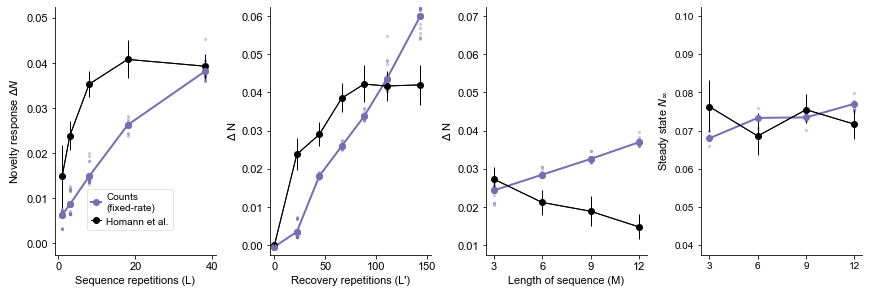

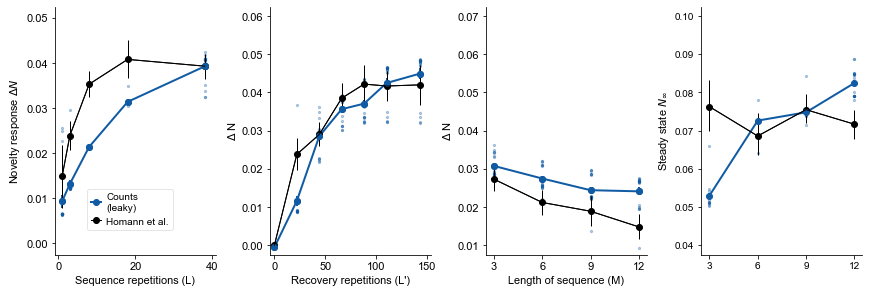

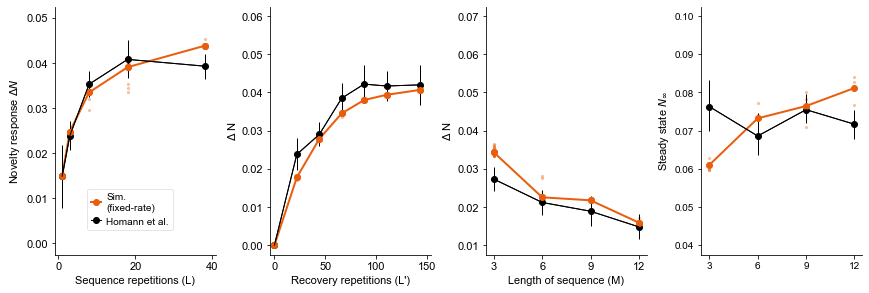

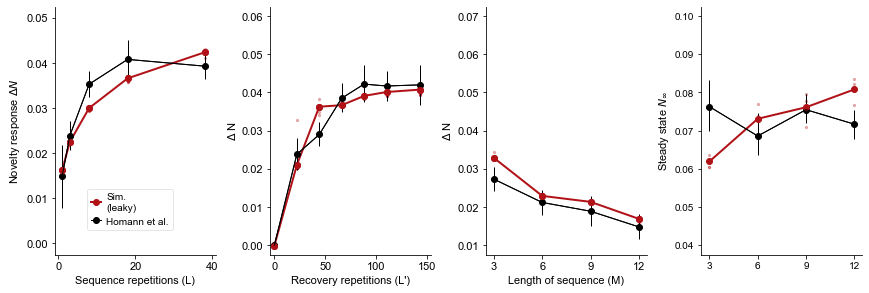

In [5]:
plot_bar_cv_si(weighting_cv='equal-samples', drop_type_cv='sample', plot_pred=True)